
Dataset shape: (541909, 11)

First 5 rows:
   InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  Year  \
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  2010   
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  2010   
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  2010   
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  2010   
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  2010   

   Total Sales  Month  
0    15.300000     12  
1    20.340001     12  
2    22.000000     12  
3    

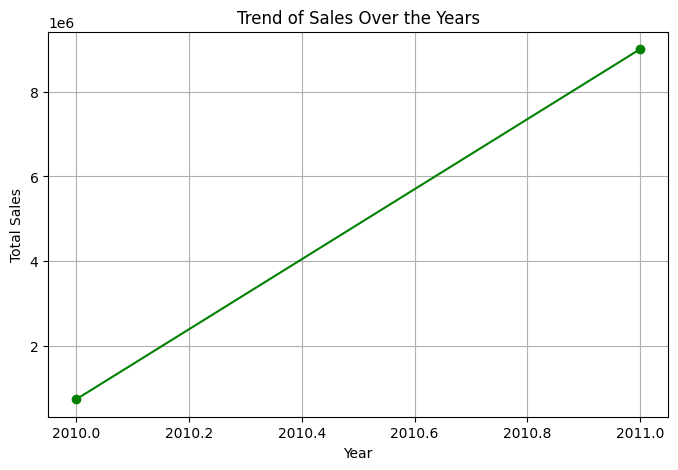

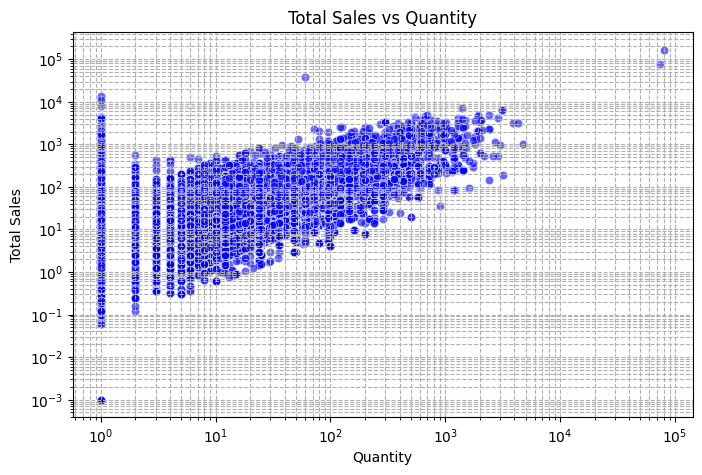

<ipython-input-5-af0b5f832cc9>:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sales_per_country.index, y=sales_per_country.values, palette='Set2')


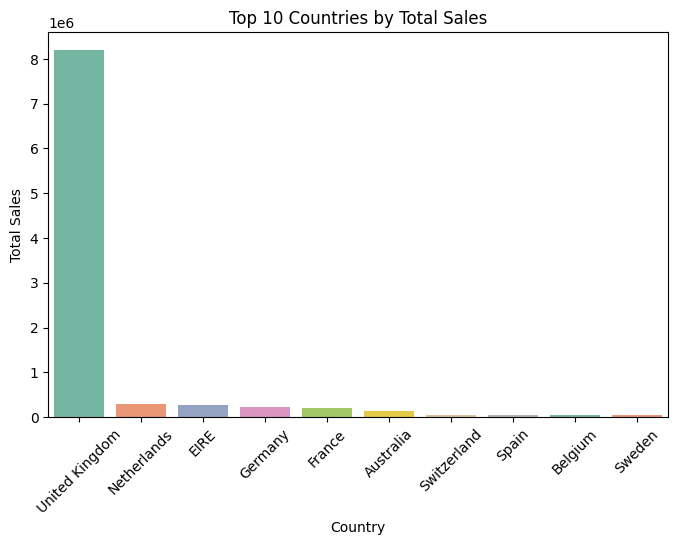

<ipython-input-5-af0b5f832cc9>:99: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_sales_dist.index, y=country_sales_dist.values, palette='coolwarm')


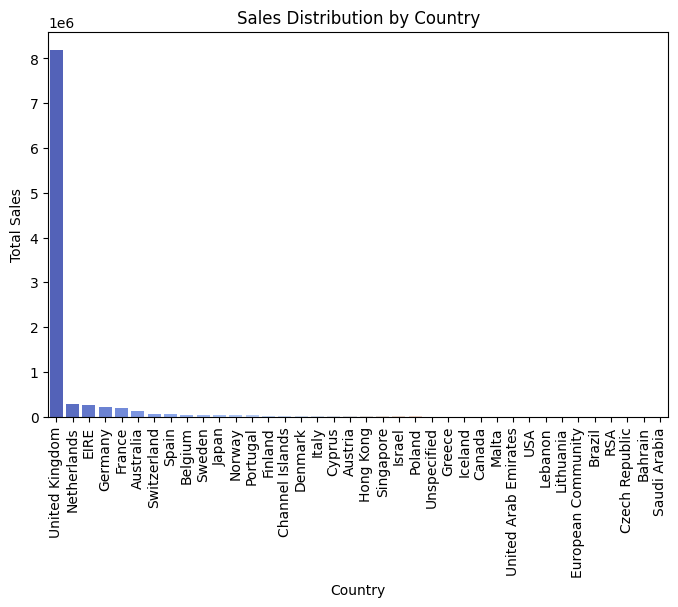

<ipython-input-5-af0b5f832cc9>:108: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.index, y=top_products.values, palette='viridis')


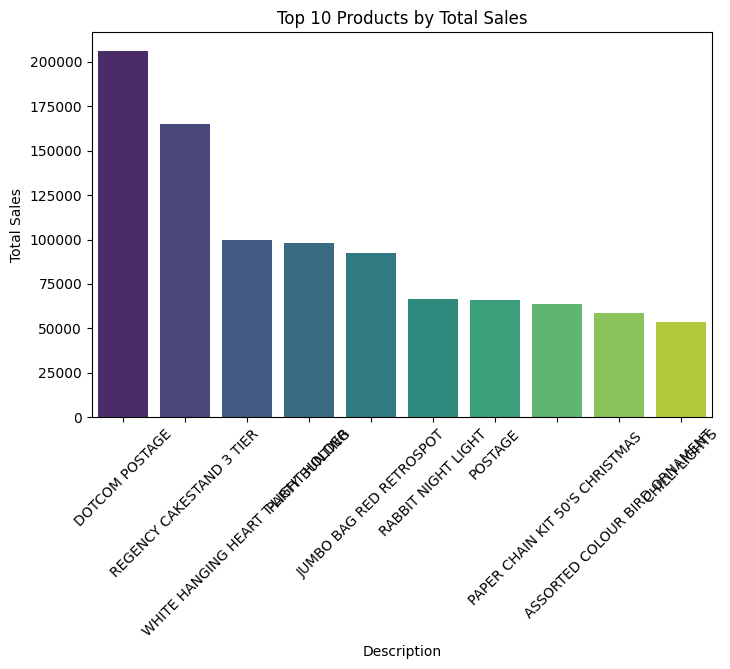

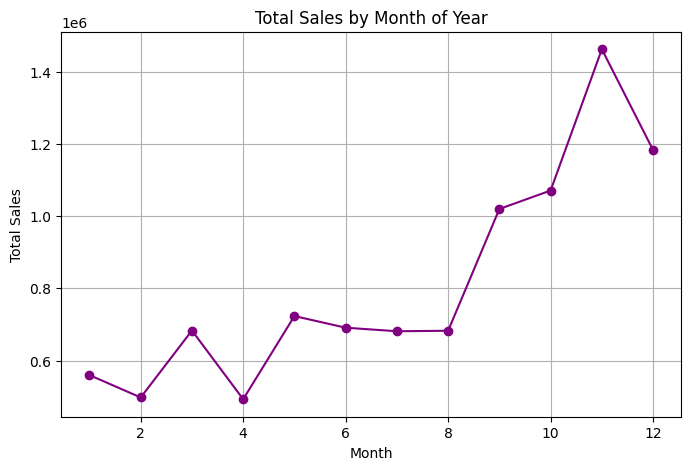

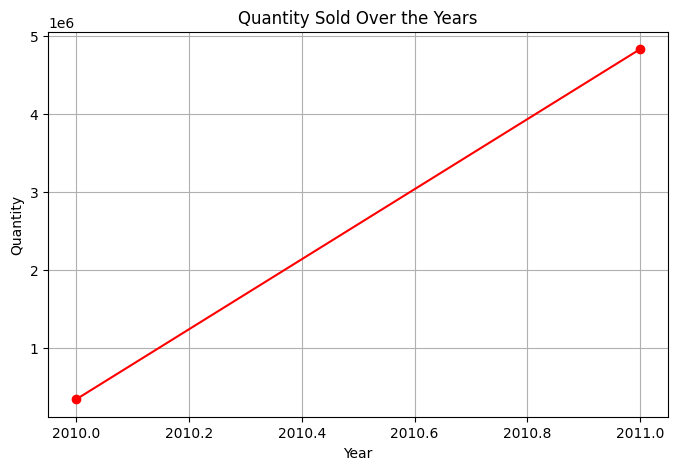

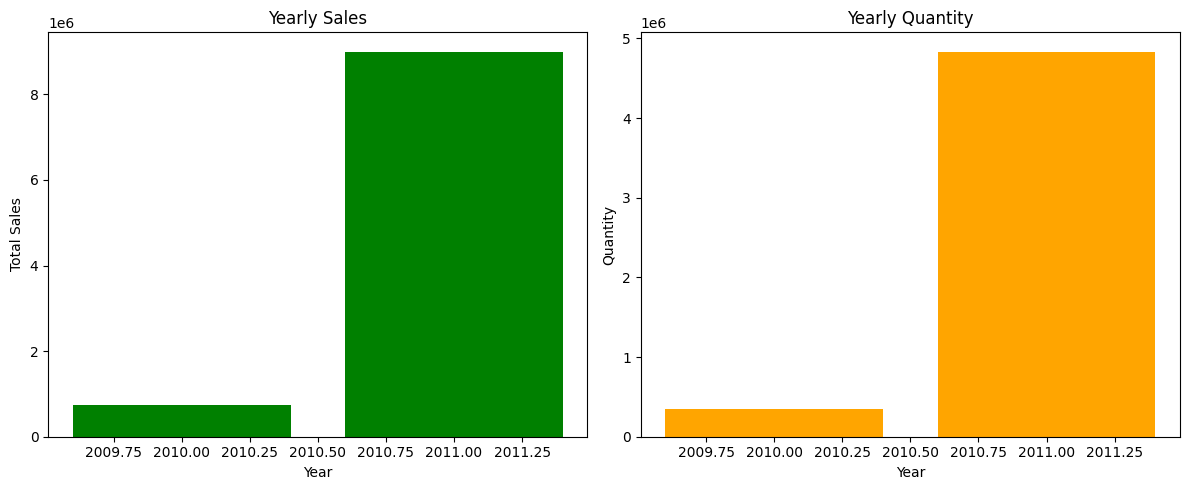


Analysis completed ✅


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
dtype = {
    'InvoiceNo': 'str',
    'StockCode': 'str',
    'Quantity': 'int32',
    'UnitPrice': 'float32',
    'CustomerID': 'float32',
    'Country': 'str'
}
print("\nDataset shape:", df.shape)
print("\nFirst 5 rows:\n", df.head())
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())

try:
    df = pd.read_csv('/content/data.csv', dtype=dtype, encoding='ISO-8859-1')
    print("Data loaded successfully!")
except Exception as e:
    print(f"Error loading data: {e}")

df['Total Sales'] = df['Quantity'] * df['UnitPrice']
sales_by_country = df.groupby('Country')['Total Sales'].sum().sort_values(ascending=False)
top_10_countries = sales_by_country.head(10)
df_top_10 = df[df['Country'].isin(top_10_countries.index)]
mean_sales = df_top_10.groupby('Country')['Total Sales'].mean()
median_sales = df_top_10.groupby('Country')['Total Sales'].median()
mode_sales = df_top_10.groupby('Country')['Total Sales'].apply(lambda x: x.mode()[0]
sales_stats = pd.DataFrame({
    'Mean Sales': mean_sales,
    'Median Sales': median_sales,
    'Mode Sales': mode_sales
})
print(sales_stats)
df['Quantity'] = df['Quantity'].fillna(0)
df['UnitPrice'] = df['UnitPrice'].fillna(0)

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')
df['Year'] = df['InvoiceDate'].dt.year

df = df.dropna(subset=['Year'])

df['Total Sales'] = df['Quantity'] * df['UnitPrice']

sales_per_year = df.groupby('Year').agg({'Total Sales': 'sum'})
plt.figure(figsize=(8, 5))
plt.plot(sales_per_year.index, sales_per_year['Total Sales'], marker='o', color='green')
plt.title('Trend of Sales Over the Years', fontsize=12)
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(x='Quantity', y='Total Sales', data=df, color='blue', alpha=0.6)
plt.title('Total Sales vs Quantity', fontsize=12)
plt.xlabel('Quantity')
plt.ylabel('Total Sales')
plt.xscale('log')
plt.yscale('log')
plt.grid(True, which="both", ls="--")
plt.show()

sales_per_country = df.groupby('Country')['Total Sales'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(8, 5))
sns.barplot(x=sales_per_country.index, y=sales_per_country.values, palette='Set2')
plt.title('Top 10 Countries by Total Sales', fontsize=12)
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

country_sales_dist = df.groupby('Country')['Total Sales'].sum().sort_values(ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(x=country_sales_dist.index, y=country_sales_dist.values, palette='coolwarm')
plt.title('Sales Distribution by Country', fontsize=12)
plt.ylabel('Total Sales')
plt.xticks(rotation=90)
plt.show()

top_products = df.groupby('Description')['Total Sales'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(8, 5))
sns.barplot(x=top_products.index, y=top_products.values, palette='viridis')
plt.title('Top 10 Products by Total Sales', fontsize=12)
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

df['Month'] = df['InvoiceDate'].dt.month
sales_per_month = df.groupby('Month').agg({'Total Sales': 'sum'})

plt.figure(figsize=(8, 5))
plt.plot(sales_per_month.index, sales_per_month['Total Sales'], marker='o', color='purple')
plt.title('Total Sales by Month of Year', fontsize=12)
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

quantity_per_year = df.groupby('Year').agg({'Quantity': 'sum'})

plt.figure(figsize=(8, 5))
plt.plot(quantity_per_year.index, quantity_per_year['Quantity'], marker='o', color='red')
plt.title('Quantity Sold Over the Years', fontsize=12)
plt.xlabel('Year')
plt.ylabel('Quantity')
plt.grid(True)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12,5))

axes[0].bar(sales_per_year.index, sales_per_year['Total Sales'], color='green')
axes[0].set_title('Yearly Sales')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Total Sales')

axes[1].bar(quantity_per_year.index, quantity_per_year['Quantity'], color='orange')
axes[1].set_title('Yearly Quantity')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Quantity')

plt.tight_layout()
plt.show()

print("\nAnalysis completed ✅")
